In [28]:
import numpy as np
import pandas as pd

def flux2mag(flux):
    return 8.9 - 2.5 * np.log10(flux)

def load_g09(region = 'all', spec_zs = 'paus',
             path_to_g09_photom= '/Users/sp624AA/Downloads/qmost_spv/G09_d1m3p1f1.parquet', 
             path_to_g09_photos= '/Users/sp624AA/Downloads/qmost_spv/G09_Photoz_Combined_Sabine Bellstedt_v3.parquet'):
    if region not in ['all', 'wide', 'deep']:
        raise ValueError(f"Unknown region {region} (must be 'all', 'wide' or 'deep')")
    
    if spec_zs not in ['paus']:
        raise ValueError(f"Unknown spec_zs {spec_zs} (must be 'paus'- mixed not implemented yet)")
    
    photom_cols_to_load = ['uberID','RAmax', 'Decmax', 'mag_Zt', 'flux_it', 'flux_gt', 'flux_Yt', 'flux_rt', 
                           'flux_Kt', 'flux_Jt','starmask', 'ghostmask', 'mask', 'class', 'duplicate']
    photom_g09 = pd.read_parquet(path_to_g09_photom, columns=photom_cols_to_load)
    photom_g09['mag_it'] = flux2mag(photom_g09['flux_it'])
    photom_g09['mag_gt'] = flux2mag(photom_g09['flux_gt'])
    photom_g09['mag_Yt'] = flux2mag(photom_g09['flux_Yt'])
    photom_g09['mag_Kt'] = flux2mag(photom_g09['flux_Kt'])
    photom_g09['mag_Jt'] = flux2mag(photom_g09['flux_Jt'])
    photom_g09['mag_rt'] = flux2mag(photom_g09['flux_rt'])
    photom_g09['g-i'] = photom_g09['mag_gt'] - photom_g09['mag_it']
    photom_g09['uberID'] = photom_g09['uberID'].astype("int64")
    mask = (
        (photom_g09['mask'] == 0) * 
        (photom_g09['starmask'] == 0) * 
        (photom_g09['ghostmask'] == 0) * 
        (photom_g09['class'] !=  'star') * 
        (photom_g09['class'] != 'artefact') *
        (photom_g09['duplicate'] == 0) *
        (photom_g09['mag_Zt'] < 21.25)
    )
    photom_g09 = photom_g09[mask]

    photo_z_cols_to_load = ['uberID', 'P020_comb', 'P080_comb' ,'zphot_invar', 
                            'zphot_err', 'z_paus', 'qz_paus', 'chi2_paus', 'z_spec', 
                            'z_NQ', 'z_source']
    photo_z_g09 = pd.read_parquet(path_to_g09_photos, columns=photo_z_cols_to_load)

    photo_z_g09.rename(columns={'zphot_invar': 'photoZ', 'zphot_err': 'photoZ_err'}, inplace=True)
    photo_z_g09['uberID'] = photo_z_g09['uberID'].astype("int64")

    photo_z_g09 = photo_z_g09[photo_z_g09['z_paus'].notna()]

    photo_z_g09['z_best'] = photo_z_g09['z_paus']

    # where z_spec is not Nan, replace z_best with z_spec
    photo_z_g09.loc[photo_z_g09['z_spec'].notna(), 'z_best'] = photo_z_g09.loc[photo_z_g09['z_spec'].notna(), 'z_spec']

    #if spec_zs == 'paus':
    # git rid of this strange value 
    #photo_z_g09 = photo_z_g09[photo_z_g09['z_best'].notna()]
    photo_z_g09 = photo_z_g09[photo_z_g09['z_best'] != 0.6729999780654907226562]


    # inner merge on uberID
    photom_g09 = photom_g09.merge(photo_z_g09, on='uberID', how='inner')
    del photo_z_g09
           
    return photom_g09

In [29]:
g09 = load_g09()

/opt/homebrew/anaconda3/envs/copula_env/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/homebrew/anaconda3/envs/copula_env/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/homebrew/anaconda3/envs/copula_env/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/homebrew/anaconda3/envs/copula_env/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/homebrew/anaconda3/envs/copula_env/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inp

In [30]:
g09

,uberID,RAmax,Decmax,mag_Zt,flux_it,flux_gt,flux_Yt,flux_rt,flux_Kt,flux_Jt,...,P080_comb,photoZ,photoZ_err,z_paus,qz_paus,chi2_paus,z_spec,z_NQ,z_source,z_best
0,132000115702153,131.486935,0.096045,17.007989,0.000449,0.000104,0.000690,0.000304,0.001267,0.000837,...,0.999866,0.199385,0.000058,0.251,0.634097,135.735001,0.255740,4.0,DESI,0.255740
1,132000140402396,131.466355,0.116294,17.513540,0.000266,0.000053,0.000455,0.000180,0.000823,0.000543,...,0.999915,0.242646,0.000075,0.254,0.397611,82.234398,0.256030,4.0,GAMA,0.256030
2,132000066300126,131.528084,-0.072853,18.835548,0.000066,0.000010,0.000134,0.000032,0.000162,0.000144,...,0.979365,0.381841,0.000002,0.585,2.008340,760.455994,NaN,NaN,NaN,0.585000
3,132000122402145,131.481352,0.095378,18.009961,0.000171,0.000034,0.000273,0.000113,0.000512,0.000327,...,1.000000,0.248193,0.000113,0.262,0.297002,61.087399,0.264648,4.0,DESI,0.264648
4,132000017000751,131.569166,-0.020776,18.550249,0.000099,0.000018,0.000178,0.000064,0.000351,0.000215,...,0.999985,0.293092,0.000313,0.311,0.369582,79.667702,0.311373,4.0,DESI,0.311373
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
92276,139981090809891,138.674303,-1.259106,21.076417,0.000011,0.000005,0.000015,0.000008,0.000015,0.000019,...,0.980232,0.195624,0.007681,0.377,13.956800,41.607601,NaN,NaN,NaN,0.377000
92277,139980886811385,138.844348,-1.134626,21.131197,0.000007,0.000003,0.000008,0.000004,0.000021,0.000014,...,0.031747,1.005849,0.001328,1.025,27.432600,49.092201,NaN,NaN,NaN,1.025000
92278,139980979408916,138.767147,-1.340364,21.188702,0.000009,0.000002,0.000016,0.000005,0.000033,0.000024,...,0.795572,0.689435,0.001851,0.920,23.437600,28.794201,NaN,NaN,NaN,0.920000
92279,139981010409295,138.741311,-1.308779,21.179129,0.000008,0.000003,0.000019,0.000004,0.000033,0.000028,...,0.047223,1.080866,0.002047,1.154,9.058150,38.113400,NaN,NaN,NaN,1.154000


z_paus
0.766    1925
0.890     565
0.814     512
0.889     502
0.815     484
         ... 
1.187       2
1.182       1
1.168       1
1.155       1
1.162       1
Name: count, Length: 1184, dtype: int64

In [6]:
g09['z_best'] = g09['z_paus']

# where z_spec is not Nan, replace z_best with z_spec
g09.loc[g09['z_spec'].notna(), 'z_best'] = g09.loc[g09['z_spec'].notna(), 'z_spec']

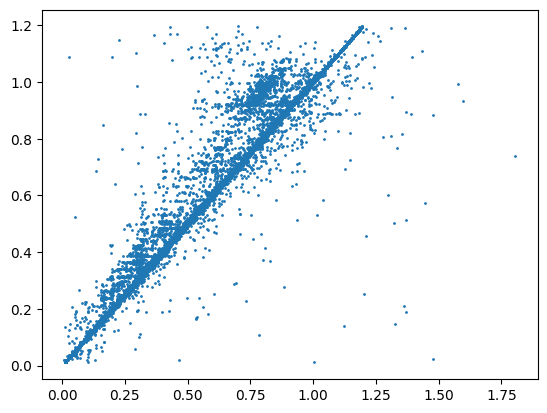

In [8]:
import matplotlib.pyplot as plt
plt.scatter(g09['z_best'], g09['z_paus'], s=1)

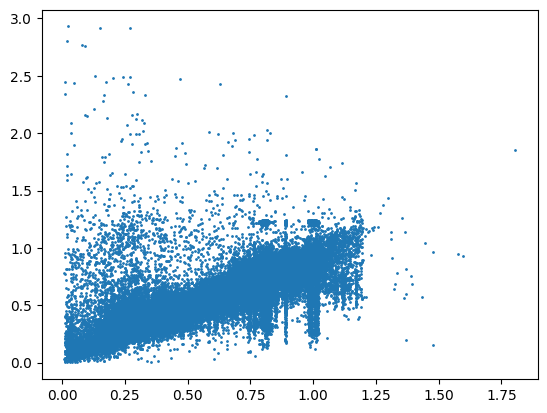

In [9]:
plt.scatter(g09['z_best'], g09['photoZ'], s=1)


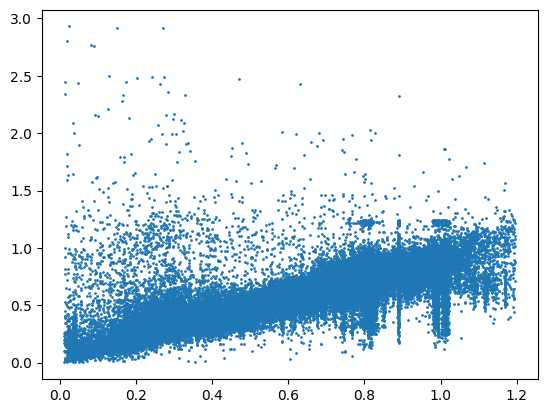

In [10]:
plt.scatter(g09['z_paus'], g09['photoZ'], s=1)